In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
INIT_LR = 0.0001
EPOCHS = 20
BS = 32
DIRECTORY = r"D:/projects/MaskDetector/dataset"
CATEGORIES = ["with_mask", "without_mask"]

In [4]:
data = []
labels = []

for category in CATEGORIES:
	path = os.path.join(DIRECTORY, category)
	for img in os.listdir(path):
		img_path = os.path.join(path, img)
		image = load_img(img_path, target_size=(224, 224))
		image = img_to_array(image)
		image = preprocess_input(image)

		data.append(image)
		labels.append(category)

d:\projects\MaskDetector\.venv\lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [5]:
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)

In [6]:
data = np.array(data, dtype="float32")
labels = np.array(labels)

In [7]:
trainX, testX, trainY, testY = train_test_split(data, labels, test_size = 0.20, stratify=labels, random_state=42)

In [8]:
aug = ImageDataGenerator(
	rotation_range=20,
	zoom_range=0.15,
	width_shift_range=0.2,
	height_shift_range=0.2,
	shear_range=0.15,
	horizontal_flip=True,
	fill_mode="nearest")

In [9]:
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))

C:\Users\slava\AppData\Local\Temp\ipykernel_6352\356392493.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))


In [10]:
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="Flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

model = Model(inputs=baseModel.input, outputs=headModel)

In [11]:
for layer in baseModel.layers:
    layer.trainable = False

In [12]:
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])

In [13]:
H = model.fit(
    aug.flow(trainX, trainY, batch_size=BS),
    steps_per_epoch=len(trainX) // BS,
    validation_data=(testX, testY),
    validation_steps=len(testX) // BS,
    epochs=EPOCHS
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 78s 709ms/step - accuracy: 0.8546 - loss: 0.3876 - val_accuracy: 0.9831 - val_loss: 0.1526
Epoch 2/20
 1/95 ━━━━━━━━━━━━━━━━━━━━ 37s 400ms/step - accuracy: 1.0000 - loss: 0.1421

d:\projects\MaskDetector\.venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 1.0000 - loss: 0.1421 - val_accuracy: 0.9831 - val_loss: 0.1511
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 642ms/step - accuracy: 0.9631 - loss: 0.1435 - val_accuracy: 0.9857 - val_loss: 0.0829
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9688 - loss: 0.1021 - val_accuracy: 0.9857 - val_loss: 0.0821
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 648ms/step - accuracy: 0.9806 - loss: 0.0856 - val_accuracy: 0.9922 - val_loss: 0.0566
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9688 - loss: 0.0783 - val_accuracy: 0.9922 - val_loss: 0.0565
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 644ms/step - accuracy: 0.9799 - loss: 0.0809 - val_accuracy: 0.9870 - val_loss: 0.0504
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9062 - loss: 0.1908 - val_accuracy: 0.9883 - val_loss: 0.0500
Epoch 9/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 653ms/step - accuracy: 0.9822 - loss: 0.0658 - val_accuracy: 0.9948 - v

In [14]:
predIdxs = model.predict(testX, batch_size=BS)
predIdxs = np.argmax(predIdxs, axis=1)

print(classification_report(testY.argmax(axis=1), predIdxs, target_names=lb.classes_))

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 401ms/step
              precision    recall  f1-score   support

   with_mask       0.99      0.99      0.99       383
without_mask       0.99      0.99      0.99       384

    accuracy                           0.99       767
   macro avg       0.99      0.99      0.99       767
weighted avg       0.99      0.99      0.99       767



In [15]:
model.save("mask_detector_model.keras")

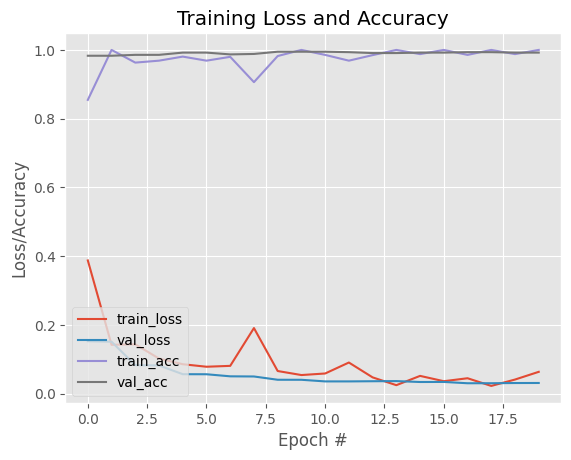

In [16]:
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")